In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.signal import butter, filtfilt


folder_path = folder_path = "C:\\Users\\Lenovo\\OneDrive\\Desktop\\heart_rate_project\\sample_data\\Subject1\\NIR-002"

#load multiple images from the folder

files = sorted(os.listdir(folder_path))

signal = []

max_frames = 500



In [2]:
# Process frames

for file in files[:max_frames]:
    if file.endswith(".pgm"):
        path = os.path.join(folder_path, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (64,64))

        h,w = img.shape
        forehead = img[h//8:h//3, w//3:2*w//3]

        # Average pixel
        avg_intensity  = np.mean(forehead)
        signal.append(avg_intensity)



In [3]:
# conver array to numpy array
signal = np.array(signal)
print("Signal Shape:", signal.shape)

Signal Shape: (500,)


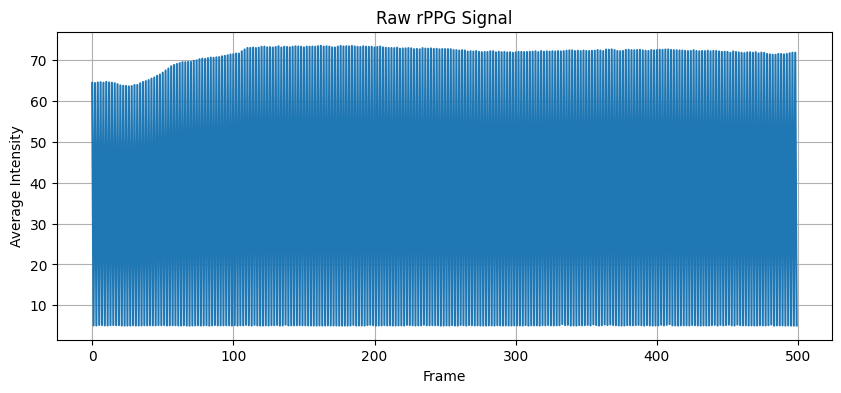

In [4]:
# Plot signal over time
plt.figure(figsize= (10,4))
plt.plot(signal)
plt.title("Raw rPPG Signal")
plt.xlabel("Frame")
plt.ylabel("Average Intensity")
plt.grid()
plt.show()

In [5]:
def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal


    #Define sampling rate
fs = 30  # Assuming 30 frames per second

# Apply bandpass filter to the raw rPPG signal

filtered_signal = bandpass_filter(signal, lowcut = 0.75, highcut = 4.0, fs = fs)

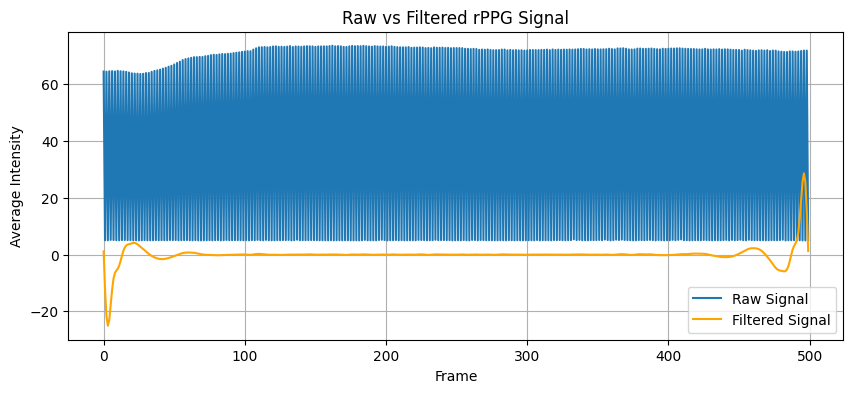

In [6]:
plt.figure(figsize= (10,4))
plt.plot(signal, label = "Raw Signal")
plt.plot(filtered_signal, label = "Filtered Signal", color = 'orange')
plt.title("Raw vs Filtered rPPG Signal")
plt.xlabel("Frame")
plt.ylabel("Average Intensity")
plt.legend()
plt.grid()
plt.show()

In [7]:
# Import peak detection library
from scipy.signal import find_peaks

# Detect peaks in the filtered signal
peaks, _ = find_peaks(filtered_signal, distance = 10)  # Minimum distance between peaks (10 frames = 0.33s at 30fps)

print("Detected Peaks at Frames:", peaks)
 # Each peak = one hearbeat, so we can calculate heart rate from the number of peaks in a given time window.

 

Detected Peaks at Frames: [ 21  60  98 110 121 131 145 162 184 205 224 235 262 283 303 321 337 356
 367 380 419 460 496]


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_23676\3045259459.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "rx" (-> color='r'). The keyword argument will take precedence.
  plt.plot(peaks, filtered_signal[peaks], "rx", label = "Detected peaks", color = 'red')


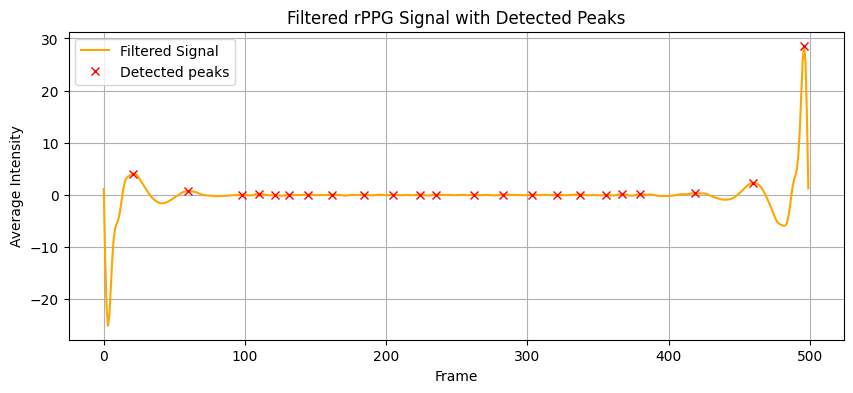

In [8]:
# Plot peaks on the filtered signal
plt.figure(figsize = (10,4))
plt.plot(filtered_signal, label = "Filtered Signal", color = 'orange')
plt.plot(peaks, filtered_signal[peaks], "rx", label = "Detected peaks", color = 'red')
plt.title("Filtered rPPG Signal with Detected Peaks")
plt.xlabel("Frame")
plt.ylabel("Average Intensity")
plt.legend()
plt.grid()
plt.show()

In [9]:
# Calculate duration of the signal in seconds
fs = 30      #frames per second
duration_sec = len(filtered_signal) / fs
print("duration of the signal in seconds:", duration_sec)



duration of the signal in seconds: 16.666666666666668


In [10]:
# BPM calculation = (number of peaks / duration in minutes) * 60
bpm = (len(peaks) / (duration_sec)) * 60
print("Estimated Heart rate (BPM):", round(bpm,2))


Estimated Heart rate (BPM): 82.8


In [11]:
# 07_data_set_creation 

import torch
from torch.utils.data import Dataset, DataLoader


In [12]:
sequence_length = 30  # Number of frames in each sequence (1 second at 30fps)
sequences = []
labels = []

# Generate frame sequneces and corresponding BPM labels
for i in range(len(filtered_signal) - sequence_length):
    sequence = []

    for j in range(sequence_length):
        file = files[i+j]
        if file.endswith(".pgm"):
            path = os.path.join(folder_path, file)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (64, 64))
            img = img / 255.0 # Normalise pixel values to [0,1]
            sequence.append(img)

    if len(sequence) == sequence_length:
        sequences.append(sequence)
        labels.append(bpm)

In [13]:
# Convert to numpy arrays
X = np.array(sequences)  # Shape: (num_samples, sequence_length, height, width)
y = np.array(labels) 

print("Dataset Shapes - X:", X.shape, "y:", y.shape)

Dataset Shapes - X: (470, 30, 64, 64) y: (470,)


In [14]:
# Add channel dimension for CNN input (num_samples, sequence_length, height, width, channels)
X = np.expand_dims(X, axis=2)  # Add channel dimension
print("Dataset Shapes after adding channel dimension - X:", X.shape, "y:", y.shape) 

Dataset Shapes after adding channel dimension - X: (470, 30, 1, 64, 64) y: (470,)


In [15]:
# Convert to Tensor
X_tensor = torch.tensor(X, dtype = torch.float32)
y_tensor = torch.tensor(y, dtype = torch.float32)

print("Tensor Shapes - X:", X_tensor.shape, "y:", y_tensor.shape)

Tensor Shapes - X: torch.Size([470, 30, 1, 64, 64]) y: torch.Size([470])


In [16]:
# again create data loader for training
train_loader = DataLoader(list(zip(X_tensor, y_tensor)))

In [17]:
#create a custom dataset class
class HeartRateDataset(Dataset):
    def __init__(self, X,y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


#

In [18]:
#create dataset object
dataset = HeartRateDataset(X_tensor, y_tensor)
print("Dataset created with", len(dataset), "samples")

Dataset created with 470 samples


In [19]:
#Model architecture will be defined in the next notebook

import torch
import torch.nn as nn

In [20]:
# Build CNN feature extractor 
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super(CNNFeatureExtractor, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
    def forward(self, X):
        x = self.cnn(X)
        X = X.view(X.size(0), -1) # Flatten for LSTM input
        return X

In [21]:
# Build a CNN model and LSTM for heart rate estimation
class CNNLSTM(nn.Module):
    def __init__(self):
        super(CNNLSTM, self).__init__()
        self.cnn_extractor = CNNFeatureExtractor()
        self.lstm = nn.LSTM(input_size = 4096, hidden_size = 128, num_layers = 1, batch_first = True)
        self.fc = nn.Linear(128,1) 
    
    def forward(self, X):
        batch_size, seq_len, c,h,w = X.size()
        cnn_features = []
        for t in range(seq_len):
            cnn_out = self.cnn_extractor(X[:,t,:,:,:]) # extract features for each frame
            cnn_features.append(cnn_out)
        cnn_features = torch.stack(cnn_features, dim = 1) # shape: (batch_size, seq_len, feature_dim)
        lstm_out, _ = self.lstm(cnn_features) 
        final_out = lstm_out[:,-1,:]
        bpm  = self.fc(final_out)
        return  bpm


In [22]:
# create model instance
model = CNNLSTM()
print(model)


CNNLSTM(
  (cnn_extractor): CNNFeatureExtractor(
    (cnn): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (lstm): LSTM(4096, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [23]:
#Test Model
dummy_input = torch.randn(2,30,1,64,64)


In [24]:
# Forward pass
Output = model(dummy_input)
print("Model output shape:", Output.shape)
print(model)


Model output shape: torch.Size([2, 1])
CNNLSTM(
  (cnn_extractor): CNNFeatureExtractor(
    (cnn): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (lstm): LSTM(4096, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)


In [25]:
# 09_training.ipynb

In [26]:
# Create DataLoader for training
train_loader = DataLoader(dataset, batch_size = 4, shuffle = True)


In [27]:
# Define loss function and optimizer
criterion = nn.MSELoss()


In [28]:
# Define optimizer
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

In [29]:
# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [30]:
# Move model to device
model.to(device)


CNNLSTM(
  (cnn_extractor): CNNFeatureExtractor(
    (cnn): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (lstm): LSTM(4096, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [32]:
# Training Loop
ephocs = 5
for epoch in range(ephocs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        y_batch = y_batch.view(-1,1)  # Reshape labels to match Output shape

        # Forward pass
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        # Backward pass and optimization
        optimizer.zero_grad()

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
    epoch_loss = running_loss / len(train_loader.dataset)
    
    print(f"Epoch [{epoch+1}/{ephocs}], Loss: {epoch_loss:.4f}")

        


Epoch [1/5], Loss: 3094.4147
Epoch [2/5], Loss: 1863.2672
Epoch [3/5], Loss: 1060.6901
Epoch [4/5], Loss: 565.8834
Epoch [5/5], Loss: 280.8135


In [33]:
#Save the trained model
torch.save(model.state_dict(), "cnn_lstm_heart_rate_model.pth")

print("Model saved successfully!")


Model saved successfully!


In [ ]:
# Create model Object 


In [ ]:
model = CNNLSTM()



In [34]:
# Load Saved weights
model.load_state_dict(torch.load("cnn_lstm_heart_rate_model.pth", ))

<All keys matched successfully>

In [35]:
# Evaluation model
model.eval()


CNNLSTM(
  (cnn_extractor): CNNFeatureExtractor(
    (cnn): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (lstm): LSTM(4096, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

In [36]:
# Select a random sample from the dataset for testing
sample_input = X_tensor[0].unsqueeze(0)
sample_label = y_tensor[0]
print("Sample_input shape:", sample_input.shape)




Sample_input shape: torch.Size([1, 30, 1, 64, 64])


In [37]:
# Predict BPM for the sample input
with torch.no_grad():
    prediction = model(sample_input)
predicted_bpm = prediction.item()
actual_bpm = sample_label.item()
print(f"Predicted BPM: {predicted_bpm:.2f}, actual BPM: {actual_bpm:.2f}")
print("Testing completed successfully!")

Predicted BPM: 69.12, actual BPM: 82.80
Testing completed successfully!


In [38]:
# Evaluate multiple samples 
predictions = []
actuals = []
with torch.no_grad():
    for i in range(20):
        sample_input = X_tensor[i].unsqueeze(0)
        pred = model(sample_input)
        predictions.append(pred.item())
        actuals.append(y_tensor[i].item())


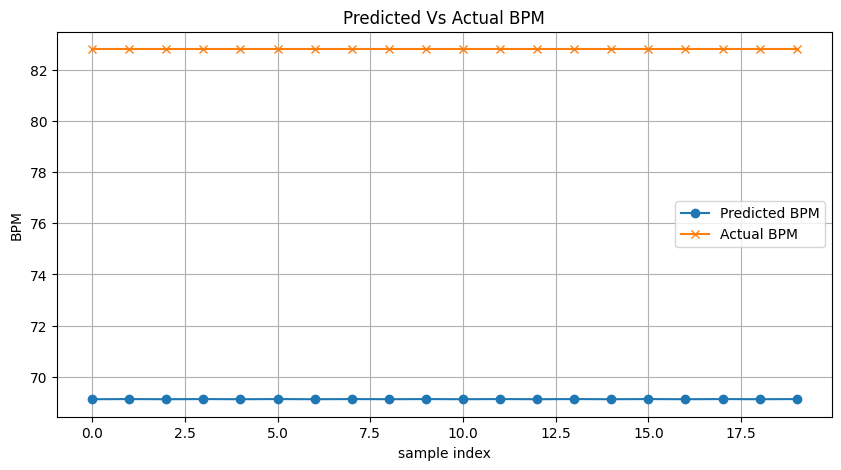

In [40]:
# Plot predicted vs actual BPM
plt.figure(figsize = (10,5))
plt.plot(predictions, label = "Predicted BPM", marker = 'o')
plt.plot(actuals, label = "Actual BPM", marker = 'x')
plt.title("Predicted Vs Actual BPM")
plt.xlabel("sample index")
plt.ylabel("BPM")
plt.legend()
plt.grid()
plt.show()

In [41]:
# Calculate MAE
mae = np.mean(np.abs(np.array(predictions) - np.array(actuals)))
print(f"Mean Absolute Error (MAE) between predicted and actual BPM: {mae:.2f}")

Mean Absolute Error (MAE) between predicted and actual BPM: 13.68
